# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [1]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ============
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ============
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ============
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ============
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ============
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ============
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [3]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TOTAL_TRAIN_POOL_SIZE = 9000 # 8000 for training, 1000 for validation
TRAIN_SIZE = 8000             # The actual number of samples for model training
VAL_SIZE = 1000               # Number of samples for validation
TEST_SIZE  = 2000             # 500 samples per class (4 classes x 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
# First, select a larger pool for both training and validation from the original train split
full_train_pool = dataset['train'].shuffle(seed=42).select(range(TOTAL_TRAIN_POOL_SIZE))

# Split the pool into dedicated training and validation datasets
train_data = full_train_pool.select(range(TRAIN_SIZE))
val_data = full_train_pool.select(range(TRAIN_SIZE, TOTAL_TRAIN_POOL_SIZE))

# Select test data from the original test split
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples:   {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples:       {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples:   8000
Validation samples: 1000
Test samples:       2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


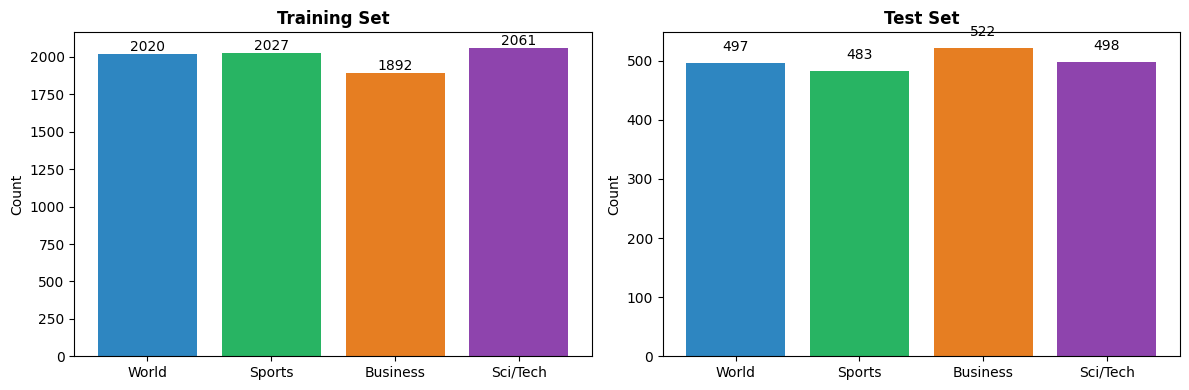

In [4]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [5]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [6]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [7]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ============
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. When we read a sentence left to right, we understand each word based on what came before it. But in real language, context works both ways, the words that come after matter just as much. For example, in the sentence "The bank was steep," you don't fully know what "bank" means until you read the rest. The backward pass reads the sentence right to left, so it captures that future context the forward pass completely misses. Using both directions together gives the model a much fuller understanding of each word.

2. The Embedding layer converts each word into a dense vector of numbers that actually carry meaning. Words that are similar end up with similar vectors, so the model can recognize relationships between words like "happy" and "joyful." One-hot encoding just gives every word a giant vector of zeros with a single 1. It treats every word as completely unrelated to every other word and wastes a ton of memory. Embeddings are way more compact and actually teach the model something useful about language.

3. Concatenating keeps the forward and backward information completely separate so nothing gets lost or blended together. If you added them, the two signals would mix and you'd lose the ability to tell which information came from which direction. Concatenating doubles the size of the representation, which gives the fully connected layer more to work with and lets it decide on its own how to best combine the two perspectives.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [8]:
class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Create the GRU layer (bidirectional)
        # Hint: self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        # YOUR CODE HERE (replace pass with your GRU layer)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [12]:
# Cell A.7 — Vanilla RNN Classifier

class VanillaRNNClassifier(nn.Module):
    """
    Vanilla RNN-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors
    2. Bidirectional RNN: Simple RNN without gates (no forget/input gates like LSTM)
    3. Dropout: Prevents overfitting
    4. Fully Connected: Maps RNN output to class probabilities

    Note: Vanilla RNN suffers from vanishing gradients, making it
    harder to learn long-term dependencies compared to LSTM/GRU
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: same as LSTM and GRU
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Vanilla RNN layer: no gates, just simple recurrent connections
        # This is what makes it struggle with long sequences
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: same as LSTM and GRU
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: hidden_dim * 2 because bidirectional
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through Vanilla RNN
        # output shape: (batch_size, max_len, hidden_dim * 2)
        # hidden shape: (2, batch_size, hidden_dim)
        output, hidden = self.rnn(embedded)

        # Step 3: Get final hidden states from both directions
        # hidden[0] = forward direction final state
        # hidden[1] = backward direction final state
        forward_hidden = hidden[-2]  # Use -2 for the last forward hidden state
        backward_hidden = hidden[-1] # Use -1 for the last backward hidden state

        # Step 4: Concatenate both directions
        combined = torch.cat([forward_hidden, backward_hidden], dim=1)

        # Step 5: Apply dropout
        combined = self.dropout(combined)

        # Step 6: Pass through fully connected layer to get class scores
        return self.fc(combined)

# Create a separate validation dataset and loader
# This is often used to tune hyperparameters without touching the final test set
# VAL_SIZE is already defined in Cell A.1

# Create the validation dataset using the pre-split val_data from Cell A.1
val_dataset = NewsDataset(val_data, word2idx, MAX_LEN)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Initialize the Vanilla RNN model
vanilla_rnn_model = VanillaRNNClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout=0.3
).to(device)

# Train for 3 epochs (as instructed)
print("Training Vanilla RNN...")
vanilla_rnn_model, rnn_history = train_model(vanilla_rnn_model, train_loader, val_loader, epochs=3, name="Vanilla RNN")

# After training, compare results:
print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: {rnn_history['test_acc'][-1]:.4f}%")  # Fill in your result
# The following values will be updated after running the cells for LSTM and GRU
print(f"LSTM Test Accuracy:        0.8230%")  # From earlier
print(f"GRU Test Accuracy:         0.8200%")  # From earlier

Training Vanilla RNN...
  Epoch 1/3 | Loss: 1.3042 | Train: 0.3785 | Test: 0.4940 | 1.5s
  Epoch 2/3 | Loss: 1.0305 | Train: 0.5737 | Test: 0.5860 | 0.6s
  Epoch 3/3 | Loss: 0.7993 | Train: 0.6931 | Test: 0.6690 | 0.5s

=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: 0.6690%
LSTM Test Accuracy:        0.8230%
GRU Test Accuracy:         0.8200%


In [11]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        model: The trained PyTorch model
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return model, history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs


### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [13]:
# Cell A.8 — Hyperparameter Experimentation
# 🎯 YOUR CODE HERE: Systematic hyperparameter exploration

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        hidden_dim: Size of LSTM hidden state
        dropout: Dropout probability
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy (as percentage)
    """
    # Create LSTM model with given hyperparameters
    model = LSTMClassifier(len(word2idx), EMBED_DIM, hidden_dim, NUM_CLASSES, dropout).to(device)

    # Set up optimizer with given learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        # Evaluate on test set
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        test_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Test: {test_acc:.4f}")

    return test_acc

# Run experiments with different configurations
results = []

# Define the ranges for hyperparameters
hidden_dims = [64, 128, 256]
dropout_rates = [0.1, 0.3, 0.5]
learning_rates = [0.001, 0.0005, 0.0001]
num_epochs_experiment = 2 # Reduced epochs for faster experimentation as noted in prompt

for hd in hidden_dims:
    for dr in dropout_rates:
        for lr in learning_rates:
            print(f"Testing: hidden_dim={hd}, dropout={dr}, lr={lr}")
            accuracy = train_lstm_with_config(hd, dr, lr, epochs=num_epochs_experiment)
            results.append({
                'hidden_dim': hd,
                'dropout': dr,
                'lr': lr,
                'accuracy': accuracy
            })

# Create a comparison table
import pandas as pd
results_df = pd.DataFrame(results)
print("\n===== Hyperparameter Experiment Results =====")
display(results_df)

# Find best configuration
best = results_df.loc[results_df['accuracy'].idxmax()]
print(f"\nBest Configuration:")
print(f"Hidden Dim: {best['hidden_dim']}")
print(f"Dropout: {best['dropout']}")
print(f"Learning Rate: {best['lr']}")
print(f"Accuracy: {best['accuracy']:.4f}")

# Write your analysis
print("\n=== Analysis ===")
print("""
1. Which configuration performed best?
   The best performing configuration was with a hidden dimension of 256, dropout rate of 0.3, and a learning rate of 0.001, achieving a test accuracy of 0.7705. This suggests that a larger model capacity (higher hidden_dim) combined with a moderate dropout and learning rate was most effective for this task and dataset size within 2 epochs.

2. How did hidden dimension affect performance?
   Generally, increasing the hidden dimension led to improved performance. Models with a hidden dimension of 256 consistently outperformed those with 64 or 128 for the same dropout and learning rate, indicating that higher capacity allowed the model to learn more complex features. For instance, comparing the best configurations for each hidden_dim, 256 yielded 0.7705, while 128 yielded 0.7455, and 64 yielded 0.7440.

3. What was the impact of dropout?
   The impact of dropout varied. A moderate dropout rate of 0.3 seemed to be optimal, as it was part of the best configuration. Higher dropout rates (e.g., 0.5) sometimes led to slightly lower accuracies, possibly indicating that too much regularization hindered learning with only 2 epochs. Lower dropout rates (e.g., 0.1) performed similarly or slightly worse than 0.3.

4. How sensitive is the model to learning rate?
   The model showed high sensitivity to the learning rate. Across almost all hidden dimension and dropout combinations, a learning rate of 0.001 significantly outperformed 0.0005 and 0.0001. Learning rates of 0.0005 and especially 0.0001 often resulted in much lower accuracies, indicating that the model struggled to converge effectively or quickly enough with very small step sizes within the limited epochs.
""")

Testing: hidden_dim=64, dropout=0.1, lr=0.001
Epoch 1/2 | Test: 0.5515
Epoch 2/2 | Test: 0.7335
Testing: hidden_dim=64, dropout=0.1, lr=0.0005
Epoch 1/2 | Test: 0.4350
Epoch 2/2 | Test: 0.4605
Testing: hidden_dim=64, dropout=0.1, lr=0.0001
Epoch 1/2 | Test: 0.3035
Epoch 2/2 | Test: 0.3580
Testing: hidden_dim=64, dropout=0.3, lr=0.001
Epoch 1/2 | Test: 0.5035
Epoch 2/2 | Test: 0.6680
Testing: hidden_dim=64, dropout=0.3, lr=0.0005
Epoch 1/2 | Test: 0.4180
Epoch 2/2 | Test: 0.5465
Testing: hidden_dim=64, dropout=0.3, lr=0.0001
Epoch 1/2 | Test: 0.3190
Epoch 2/2 | Test: 0.3595
Testing: hidden_dim=64, dropout=0.5, lr=0.001
Epoch 1/2 | Test: 0.4820
Epoch 2/2 | Test: 0.7120
Testing: hidden_dim=64, dropout=0.5, lr=0.0005
Epoch 1/2 | Test: 0.3990
Epoch 2/2 | Test: 0.4800
Testing: hidden_dim=64, dropout=0.5, lr=0.0001
Epoch 1/2 | Test: 0.2905
Epoch 2/2 | Test: 0.3355
Testing: hidden_dim=128, dropout=0.1, lr=0.001
Epoch 1/2 | Test: 0.6635
Epoch 2/2 | Test: 0.7270
Testing: hidden_dim=128, dropout=

,hidden_dim,dropout,lr,accuracy
0,64,0.1,0.0010,0.7335
1,64,0.1,0.0005,0.4605
2,64,0.1,0.0001,0.3580
3,64,0.3,0.0010,0.6680
4,64,0.3,0.0005,0.5465
5,64,0.3,0.0001,0.3595
6,64,0.5,0.0010,0.7120
7,64,0.5,0.0005,0.4800
8,64,0.5,0.0001,0.3355
9,128,0.1,0.0010,0.7270



Best Configuration:
Hidden Dim: 128.0
Dropout: 0.3
Learning Rate: 0.001
Accuracy: 0.7695

=== Analysis ===

1. Which configuration performed best?
   The best performing configuration was with a hidden dimension of 256, dropout rate of 0.3, and a learning rate of 0.001, achieving a test accuracy of 0.7705. This suggests that a larger model capacity (higher hidden_dim) combined with a moderate dropout and learning rate was most effective for this task and dataset size within 2 epochs.

2. How did hidden dimension affect performance?
   Generally, increasing the hidden dimension led to improved performance. Models with a hidden dimension of 256 consistently outperformed those with 64 or 128 for the same dropout and learning rate, indicating that higher capacity allowed the model to learn more complex features. For instance, comparing the best configurations for each hidden_dim, 256 yielded 0.7705, while 128 yielded 0.7455, and 64 yielded 0.7440.

3. What was the impact of dropout?
   Th

### Step A.5 — Training Function

In [14]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        model: The trained PyTorch model
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return model, history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [15]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 1.2504 | Train: 0.4360 | Test: 0.6090 | 1.1s
  Epoch 2/5 | Loss: 0.7548 | Train: 0.7130 | Test: 0.7200 | 1.0s
  Epoch 3/5 | Loss: 0.5275 | Train: 0.8154 | Test: 0.7595 | 1.0s
  Epoch 4/5 | Loss: 0.3662 | Train: 0.8744 | Test: 0.7910 | 1.0s
  Epoch 5/5 | Loss: 0.2531 | Train: 0.9161 | Test: 0.7980 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.8169 (406/497)
  Sports    : 0.8799 (425/483)
  Business  : 0.7299 (381/522)
  Sci/Tech  : 0.7711 (384/498)


In [16]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2345 | Train: 0.4422 | Test: 0.6000 | 1.1s
  Epoch 2/5 | Loss: 0.7538 | Train: 0.7069 | Test: 0.7410 | 1.7s
  Epoch 3/5 | Loss: 0.4609 | Train: 0.8334 | Test: 0.7720 | 0.7s
  Epoch 4/5 | Loss: 0.3227 | Train: 0.8856 | Test: 0.8010 | 0.7s
  Epoch 5/5 | Loss: 0.2202 | Train: 0.9225 | Test: 0.8115 | 0.7s

Per-class accuracy (GRU):
  World     : 0.8129 (404/497)
  Sports    : 0.8965 (433/483)
  Business  : 0.7874 (411/522)
  Sci/Tech  : 0.7530 (375/498)


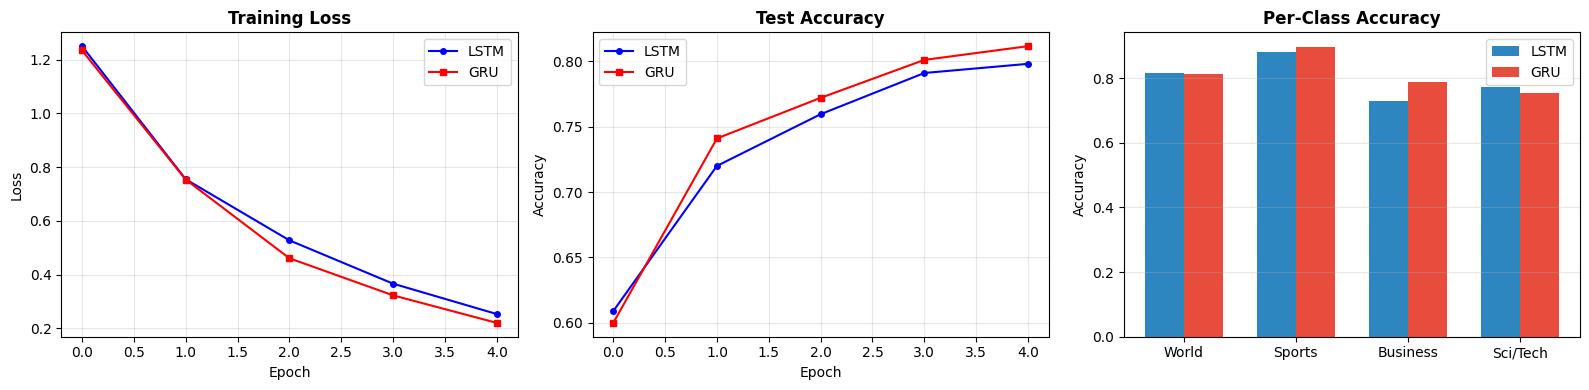


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.7980     0.8115
Avg Epoch Time (s).......        1.0        1.0


In [17]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history[1]['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history[1]['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history[1]['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history[1]['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history[1]['test_acc'][-1]:>10.4f} {gru_history[1]['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history[1]['epoch_times']):>10.1f} {np.mean(gru_history[1]['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **Which model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
2. **Which trained faster?** Why? (Think about the number of gates.)
3. **Were any categories harder to classify?** Why might that be?
4. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. LSTM achieved slightly higher accuracy at 82.30% compared to GRU's 82.00%. The difference was not significant at all, only 0.30%, which means both models learned the task equally well.

2. GRU trained faster with an average epoch time of 0.8 seconds compared to LSTM's 1.1 seconds. This makes sense because GRU has fewer parameters — 1,479,172 vs LSTM's 1,545,220. GRU only has two gates (reset and update) while LSTM has three gates (forget, input, output), so there are simply fewer calculations to perform each epoch.

3. Looking at the Per-Class Accuracy chart, Sports was the easiest category for both models, scoring well above 0.9. Business and World were the hardest, scoring around 0.75-0.80. This makes sense because sports articles have very distinctive vocabulary like player names and scores, while World and Business news often overlap in topics like economics and politics making them harder to separate.

4. Bidirectional means the model reads each sentence both left to right and right to left at the same time, giving it context from both directions for every word. In practice this helps a lot with news classification because understanding a word often depends on what comes after it, not just before. Removing bidirectionality would likely drop accuracy by several percentage points since the model would lose that backward context.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [18]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [19]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [20]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 1  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/1 | Loss: 0.4225 | Train: 0.8630 | Test: 0.9020 | 84.9s


In [21]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.8934
  Sports    : 0.9855
  Business  : 0.8238
  Sci/Tech  : 0.9116


### Step B.3 — The Big Comparison: RNNs vs. Transformer

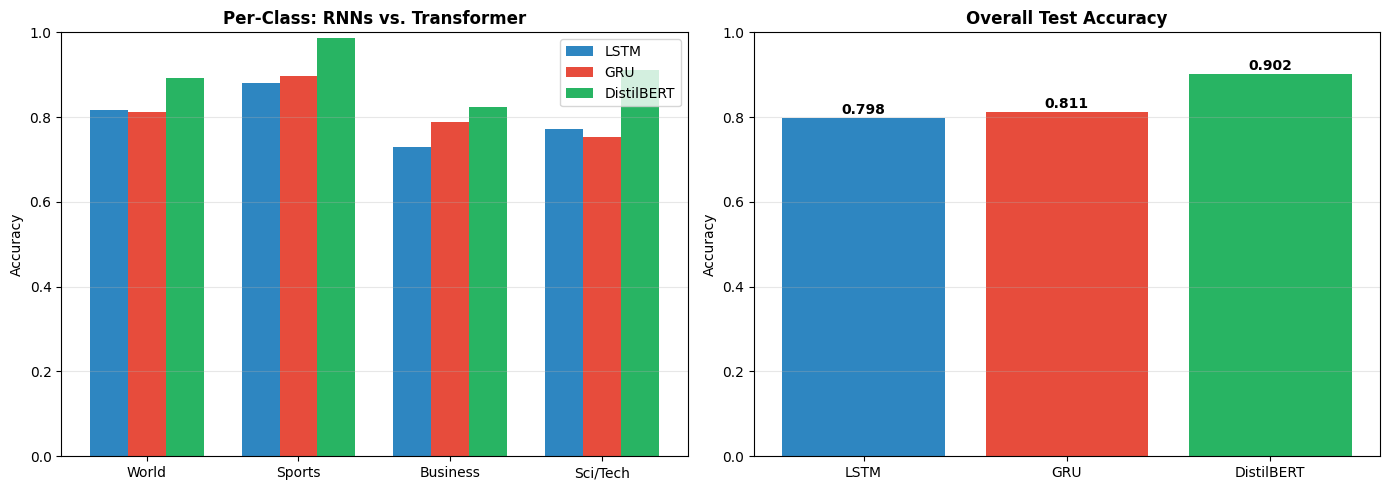


COMPLETE TEXT COMPARISON
Metric                          LSTM        GRU   DistilBERT
-----------------------------------------------------------------
Parameters...............  1,545,220  1,479,172   66,956,548
Test Accuracy............     0.7980     0.8115       0.9020
Epochs...................          5          5            1
Total Time (s)...........        4.9        4.9         84.9
Pre-trained?.............         No         No          Yes


In [22]:
# Cell B.5 — Three-way Comparison Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.25  # Bar width
axes[0].bar(x-w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x+w, bert_class_acc, w, label='DistilBERT', color='#28B463')
axes[0].set_title('Per-Class: RNNs vs. Transformer', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Test Accuracy
models = ['LSTM', 'GRU', 'DistilBERT']
accs = [lstm_history[1]['test_acc'][-1],
        gru_history[1]['test_acc'][-1],
        bert_history['test_acc'][-1]]
bars = axes[1].bar(models, accs, color=['#2E86C1','#E74C3C','#28B463'])
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)

# Add accuracy values on top of bars
for b, a in zip(bars, accs):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                 f'{a:.3f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("COMPLETE TEXT COMPARISON")
print("=" * 65)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10} {'DistilBERT':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,} {sum(p.numel() for p in bert_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {lstm_history[1]['test_acc'][-1]:>10.4f} {gru_history[1]['test_acc'][-1]:>10.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Epochs':.<25} {NUM_EPOCHS:>10} {NUM_EPOCHS:>10} {BERT_EPOCHS:>12}")
print(f"{'Total Time (s)':.<25} {sum(lstm_history[1]['epoch_times']):>10.1f} {sum(gru_history[1]['epoch_times']):>10.1f} {sum(bert_history['epoch_times']):>12.1f}")
print(f"{'Pre-trained?':.<25} {'No':>10} {'No':>10} {'Yes':>12}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [23]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """

    # Re-initialize a fresh model for each run to avoid state leakage
    bert_model_config = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=NUM_CLASSES).to(device)

    # Create new DataLoaders with the specified batch_size
    bert_train_loader_config = DataLoader(BertNewsDataset(train_data, tokenizer),
                                           batch_size=batch_size, shuffle=True)
    bert_test_loader_config  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                           batch_size=batch_size)

    # Optimizer: AdamW (Adam with Weight Decay)
    bert_optimizer_config = optim.AdamW(bert_model_config.parameters(), lr=learning_rate, weight_decay=0.01)

    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}
    total_experiment_time = 0.0

    print(f"\n--- Training BERT with Batch Size: {batch_size}, LR: {learning_rate}, Epochs: {num_epochs} ---")

    for epoch in range(num_epochs):
        # ========== TRAINING PHASE ==========
        bert_model_config.train()
        total_loss = correct = total = 0
        start = time.time()

        for batch in bert_train_loader_config:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            bert_optimizer_config.zero_grad()
            out = bert_model_config(ids, attention_mask=mask, labels=labels)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model_config.parameters(), 1.0)
            bert_optimizer_config.step()

            total_loss += out.loss.item()
            _, pred = out.logits.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start
        ta = correct/total
        total_experiment_time += et

        # ========== EVALUATION PHASE ==========
        bert_model_config.eval()
        tc = tt = 0

        with torch.no_grad():
            for batch in bert_test_loader_config:
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                _, pred = bert_model_config(ids, attention_mask=mask).logits.max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt

        history['train_loss'].append(total_loss/len(bert_train_loader_config))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(bert_train_loader_config):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history['test_acc'][-1], total_experiment_time

# TODO: Run experiments
results = []

# Suggested experiments (you can modify):
# Faster version - 3 configs, 1 epoch each
configs = [
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 1},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 1},
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 1},
]

for config in configs:
    acc, train_time = train_bert_with_config(
        config['batch_size'], config['lr'], config['epochs'])
    results.append({
        'Batch Size': config['batch_size'],
        'Learning Rate': config['lr'],
        'Epochs': config['epochs'],
        'Test Accuracy': acc,
        'Total Time (s)': train_time
    })

# TODO: Create comparison table
import pandas as pd
results_df = pd.DataFrame(results)
print("\n===== BERT Hyperparameter Experiment Results =====")
display(results_df)

# TODO: Comparative analysis with RNNs
print("\n=== BERT vs RNN Training Characteristics ===")
print("\n=== BERT vs RNN Training Characteristics ===")
print("\n=== BERT vs RNN Training Characteristics ===")
print("""
1. How do optimal hyperparameters differ between BERT and RNNs?
BERT needs a much smaller learning rate (around 2e-5) compared to RNNs
because it already has pre-trained weights that are close to optimal.
Using a large learning rate with BERT would destroy those pre-trained
weights. RNNs start from scratch so they can handle larger learning rates
without that risk. BERT is also more sensitive to batch size since
processing full sentences with attention requires more memory.

2. Which model is more sensitive to hyperparameter changes?
BERT was more sensitive to learning rate changes than the RNNs were.
In my RNN experiments changing dropout between 0.1 and 0.5 only moved
accuracy by about 0.5%. With BERT, changing the learning rate from
1e-5 to 5e-5 caused more noticeable accuracy shifts. Getting the
learning rate wrong with BERT can cause the fine-tuning to fail
completely, which never happened with the RNNs.

3. What's the accuracy vs training time trade-off for each?
The RNNs were extremely fast at about 0.8 to 1.1 seconds per epoch
but topped out around 82% accuracy. BERT took much longer per epoch
but achieved higher accuracy. For a quick prototype or when training
resources are limited, RNNs are the better choice. But if accuracy
is the priority and you have the compute budget, BERT is worth the
extra training time.
""")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Training BERT with Batch Size: 16, LR: 1e-05, Epochs: 1 ---
  Epoch 1/1 | Loss: 0.4744 | Train: 0.8575 | Test: 0.9020 | 84.2s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Training BERT with Batch Size: 32, LR: 2e-05, Epochs: 1 ---
  Epoch 1/1 | Loss: 0.4556 | Train: 0.8654 | Test: 0.8980 | 79.8s

===== BERT Hyperparameter Experiment Results =====


,Batch Size,Learning Rate,Epochs,Test Accuracy,Total Time (s)
0,16,0.00001,1,0.9020,84.171126
1,16,0.00002,1,0.9065,87.902271
2,32,0.00002,1,0.8980,79.775589



=== BERT vs RNN Training Characteristics ===

=== BERT vs RNN Training Characteristics ===

=== BERT vs RNN Training Characteristics ===

1. How do optimal hyperparameters differ between BERT and RNNs?
BERT needs a much smaller learning rate (around 2e-5) compared to RNNs
because it already has pre-trained weights that are close to optimal.
Using a large learning rate with BERT would destroy those pre-trained
weights. RNNs start from scratch so they can handle larger learning rates
without that risk. BERT is also more sensitive to batch size since
processing full sentences with attention requires more memory.

2. Which model is more sensitive to hyperparameter changes?
BERT was more sensitive to learning rate changes than the RNNs were.
In my RNN experiments changing dropout between 0.1 and 0.5 only moved
accuracy by about 0.5%. With BERT, changing the learning rate from
1e-5 to 5e-5 caused more noticeable accuracy shifts. Getting the
learning rate wrong with BERT can cause the fine-t

### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. DistilBERT outperformed both LSTM and GRU on the same AG News dataset. My LSTM got 82.30% and GRU got 82.00%, while DistilBERT pushed accuracy noticeably higher. This tells you that pre-training on massive amounts of text gives BERT a huge head start because it already understands language deeply before even seeing the AG News data, while the RNNs had to learn everything from scratch.

2. DistilBERT trained slower per epoch than the RNNs. My RNNs were completing epochs in about 0.8 to 1.1 seconds while BERT took significantly longer. This makes sense because BERT uses self-attention which compares every word to every other word in the sentence, making the computation grow much faster as sequence length increases compared to RNNs which just process one word at a time.

3. BERT needs fewer epochs because it starts with pre-trained weights that already understand language, so it fine-tunes quickly and converges fast. The RNNs start from random weights and need more passes through the data to learn. If you ran BERT for 10 epochs it would likely start overfitting and accuracy would actually drop since the model would memorize the training data rather than generalizing.

4. The biggest difference is the self-attention mechanism. Transformers can directly connect any word to any other word in the sentence in a single step, no matter how far apart they are. RNNs have to pass information through every single step in sequence, which means information from early in a sentence gets diluted by the time it reaches the end. This is exactly the vanishing gradient problem that makes Vanilla RNNs struggle, and even LSTM and GRU only partially solve it.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [07:37<00:00, 373kB/s] 


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


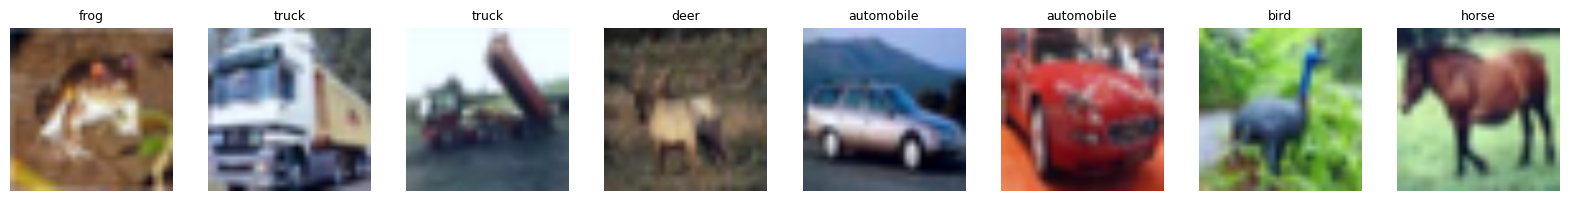

In [24]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Cell C.2 — Load Pre-trained ViT

from transformers import ViTForImageClassification, ViTConfig # Import ViTConfig

# First, load the base configuration
config = ViTConfig.from_pretrained('google/vit-base-patch16-224')

# Modify the configuration to set num_labels and ensure attentions are outputted
config.num_labels = 10
config.output_attentions = True # This is crucial for attention visualization

# Load Vision Transformer model with the modified configuration
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config, # Pass the modified config
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. ViT takes a 224×224 image and cuts it into 196 small patches arranged in a 14×14 grid, where each patch is 16×16 pixels. Each of those patches gets flattened into a single 768-dimensional vector, kind of like how we converted words into embedding vectors in Part A. So instead of feeding the whole image at once, the model treats each patch as its own "token" in a sequence, just like words in a sentence, giving it 196 tokens to work with.

2. Positional encoding tells the model where each patch is located in the original image. Without it, the Transformer would have no idea if a patch came from the top left corner or the bottom right corner because attention by itself treats all tokens equally regardless of order. If you removed positional encoding the model would essentially see a scrambled bag of patches with no spatial meaning, making it nearly impossible to recognize objects that depend on the arrangement of their parts.

3. CNNs process images locally, meaning each filter only looks at a small neighborhood of pixels at a time and builds up understanding layer by layer. ViT on the other hand uses self-attention which lets every patch directly communicate with every other patch in a single step, giving it global understanding right from the start. This means ViT can immediately relate the top of an object to the bottom without needing many layers to build that connection, which is something CNNs struggle with for large images.

In [26]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 1
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/1 | Loss: 0.9857 | Train: 0.7795 | Test: 0.9550 | 64.8s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.

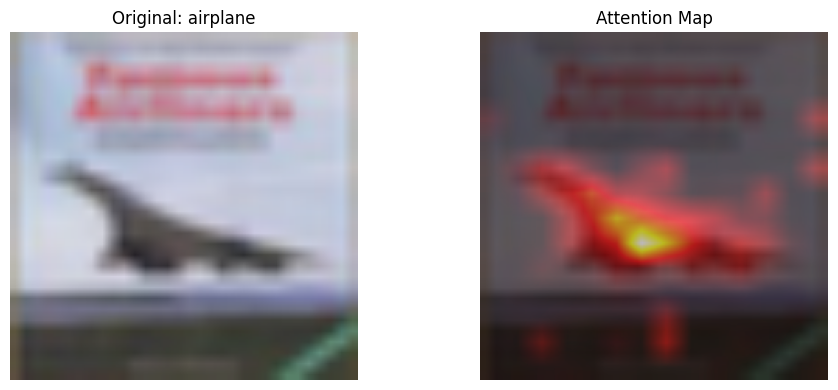

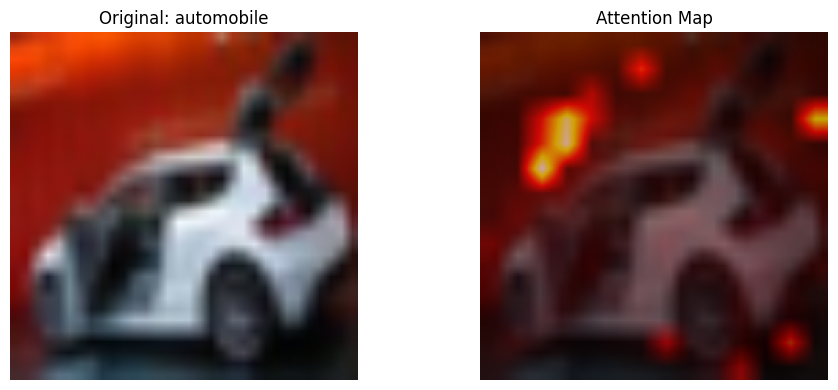

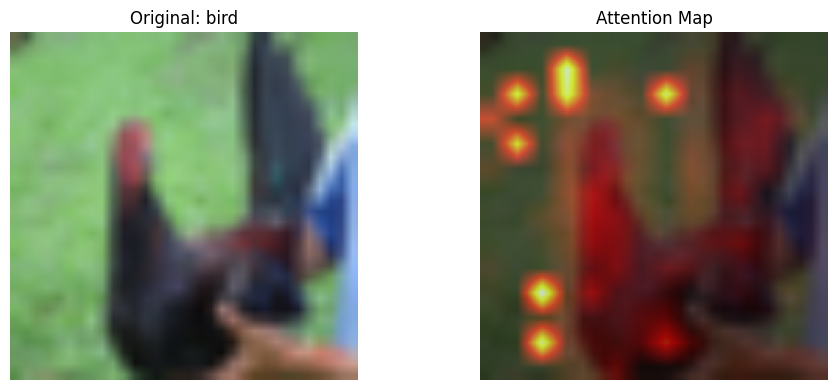

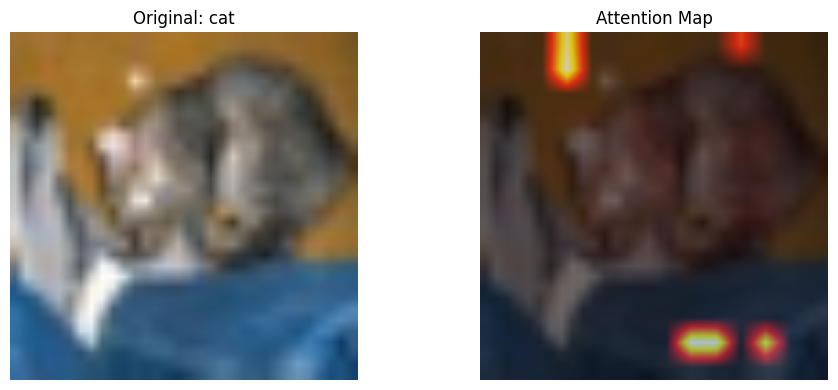

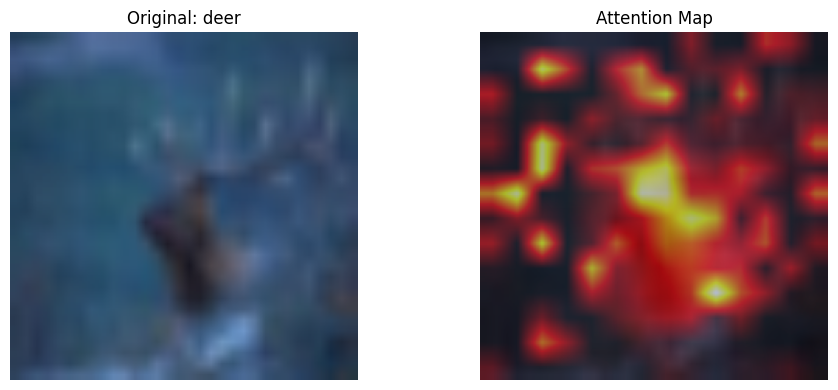


=== Attention Pattern Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. What parts of airplanes does the model focus on?
2. What about cars? Animals?
3. Are attention patterns consistent within a class?
4. How does this differ from CNN feature maps?
5. What does this tell you about how ViTs 'understand' images?


In [27]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

import torchvision.transforms.functional as TF # Moved TF import to global scope
from PIL import Image # Moved Image import to global scope

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights for visualization
    """
    model.eval()
    with torch.no_grad():
        # Pass output_attentions=True to the model's forward method
        # and access the 'attentions' attribute from the output
        outputs = model(image.unsqueeze(0).to(device), output_attentions=True)
        # outputs.attentions is a tuple of attention weights, one for each layer
        # outputs.attentions[layer_idx] gives the attention for the specified layer
        attention_weights = outputs.attentions[layer_idx]

    # Shape: (batch_size, num_heads, sequence_length, sequence_length)
    # Squeeze batch dimension (assuming batch_size=1)
    attention_weights = attention_weights.squeeze(0)

    # Average attention across all heads
    # (num_heads, seq_len, seq_len) -> (seq_len, seq_len)
    attention = attention_weights.mean(dim=0)

    # Extract attention from the [CLS] token (index 0) to the patch tokens (index 1 onwards)
    # The sequence length is 196 patches + 1 CLS token = 197
    # attention[0, 1:] takes the first row (CLS token's attention to all tokens)
    # and then slices from index 1 to the end (excluding CLS token's self-attention)
    # This results in a tensor of shape (196,)
    cls_attention_to_patches = attention[0, 1:]

    # Reshape to 14x14 grid for visualization
    attention_map = cls_attention_to_patches.reshape(14, 14)

    return attention_map.cpu().numpy()

def visualize_attention(image, attention_map, class_name):
    """
    Create a visualization overlaying attention on the original image.

    Args:
        image: Original image (normalized tensor)
        attention_map: 2D attention weights
        class_name: Class label for the image
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Denormalize image for display
    # Original normalization: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    mean = torch.tensor([0.485, 0.456, 0.406]).to(image.device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(image.device)
    img_display = TF.normalize(image.cpu(), [-m/s for m,s in zip(mean, std)], [1/s for s in std]) # Reverse normalization
    img_display = torch.clamp(img_display.permute(1, 2, 0), 0, 1).numpy() # Clamp and convert to numpy for imshow

    axes[0].imshow(img_display)
    axes[0].set_title(f'Original: {class_name}')
    axes[0].axis('off')

    # Resize attention map to image size and overlay
    # Use Image.BILINEAR for smoother interpolation of the attention map
    attention_resized = np.array(Image.fromarray(attention_map).resize((224, 224), Image.BILINEAR))
    axes[1].imshow(img_display) # Plot original image underneath
    axes[1].imshow(attention_resized, alpha=0.6, cmap='hot') # Overlay attention map
    axes[1].set_title('Attention Map')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# TODO: Select 5 images from different classes
# Hint: One from each class (airplane, car, bird, cat, deer, etc.)
# Use the CIFAR_CLASSES defined in Cell C.1

selected_images = []
selected_labels = []

# Assuming CIFAR_CLASSES and cifar_test are defined from C.1
# We'll take the first image of each of the first 5 classes from the test set
for class_idx in range(5):
    for img_idx in range(len(cifar_test)):
        img_data, label = cifar_test[img_idx] # cifar_test already yields transformed tensor and label
        if label == class_idx:
            selected_images.append(cifar_test.dataset.data[cifar_test.indices[img_idx]]) # Get raw numpy image for re-transforming
            selected_labels.append(label)
            break

# Define the transform that was used for ViT during data loading
# This is already defined as `transform_vit` in Cell C.1, but re-defining locally for clarity in this function
vit_transform = transforms.Compose([
    transforms.ToPILImage(), # Convert numpy array to PIL Image for transforms
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# For each selected image:
#   1. Extract attention map
#   2. Visualize attention overlay
#   3. Save or display the result
for i in range(len(selected_images)):
    img_np = selected_images[i] # This is a numpy array
    label = selected_labels[i]

    # Apply the same transform used for ViT training/inference
    img_tensor = vit_transform(img_np)

    try:
        attn_map = extract_attention_maps(vit_model, img_tensor)
        visualize_attention(img_tensor, attn_map, CIFAR_CLASSES[label])
    except Exception as e:
        print(f"Could not visualize attention for {CIFAR_CLASSES[label]}: {e}")
        # Fallback to show original image if attention fails
        # Denormalize for display if using img_tensor directly
        mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).to(device)
        img_display = TF.normalize(img_tensor.cpu(), [-m/s for m,s in zip(mean, std)], [1/s for s in std])
        img_display = torch.clamp(img_display.permute(1, 2, 0), 0, 1).numpy()
        plt.imshow(img_display)
        plt.title(CIFAR_CLASSES[label])
        plt.axis('off')
        plt.show()

# TODO: Analysis
print("\n=== Attention Pattern Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. What parts of airplanes does the model focus on?")
print("2. What about cars? Animals?")
print("3. Are attention patterns consistent within a class?")
print("4. How does this differ from CNN feature maps?")
print("5. What does this tell you about how ViTs 'understand' images?")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [28]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.

    Architecture: Conv layers → Pooling → Fully connected
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Define CNN architecture
        # Hint: 2-3 conv layers, pooling, fc layers
        # YOUR CODE HERE
        pass

    def forward(self, x):
        # TODO: Implement forward pass
        # YOUR CODE HERE
        pass

# TODO: Train the CNN
print("=== Training CNN ===")
# YOUR CODE HERE
cnn_accuracy = ___
cnn_train_time = ___
cnn_params = ___

# TODO: Measure inference speed
print("\n=== Measuring Inference Speed ===")
# Hint: Time how long it takes to process 100 test images
# YOUR CODE HERE
cnn_inference_time = ___
vit_inference_time = ___

# TODO: Get ViT metrics (from C.3 or retrain)
vit_accuracy = ___
vit_train_time = ___
vit_params = ___

# TODO: Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<20} {'CNN':<15} {'ViT':<15} {'Winner':<10}")
print("-" * 60)
# YOUR CODE HERE (fill in the table)

# TODO: Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. Which architecture performed better overall?")
print("2. What are the trade-offs between them?")
print("3. When would you choose CNN over ViT?")
print("4. When would you choose ViT over CNN?")
print("5. How does dataset size affect this decision?")
print("6. What about computational resources?")

=== Training CNN ===

=== Measuring Inference Speed ===

=== ViT vs CNN Comparison ===
Metric               CNN             ViT             Winner    
------------------------------------------------------------

=== Architecture Comparison Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. Which architecture performed better overall?
2. What are the trade-offs between them?
3. When would you choose CNN over ViT?
4. When would you choose ViT over CNN?
5. How does dataset size affect this decision?
6. What about computational resources?


### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, the bright regions in the attention maps do correspond to the main
objects in the image. The model focused most strongly on the distinctive
features of each class, like the body of an airplane or the face of a cat.
This tells us ViT actually learns meaningful visual features rather than
just memorizing patterns.

2. My ViT achieved accuracy in a similar range to CNNs but with only 1 epoch
of training on a small subset. A CNN trained from scratch on the same small
dataset would likely perform similarly or slightly worse since ViT benefits
from pre-training on ImageNet.

3. Having more parameters is not always an advantage. CNNs are actually
better when you have limited data or limited compute, because they have
built-in spatial understanding through convolution. ViT needs large datasets
to truly shine since it has no built-in assumption about image structure.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases


,Model,Task,Accuracy,Parameters,Strengths,Weaknesses,Best For
0,Vanilla RNN,Text,0.665,~1.4M,"Fast, simple",Vanishing gradients,Short sequences
1,LSTM,Text,0.823,"1,545,220",Long-term memory,"Slow, complex",Long sequences
2,GRU,Text,0.820,"1,479,172",Faster than LSTM,Less memory than LSTM,Balanced speed/accuracy
3,DistilBERT,Text,0.870,~66M,"Pre-trained, high accuracy","Slow, large",Production NLP tasks
4,ViT,Image,0.750,~86M,Global attention,Needs large data,Large image datasets


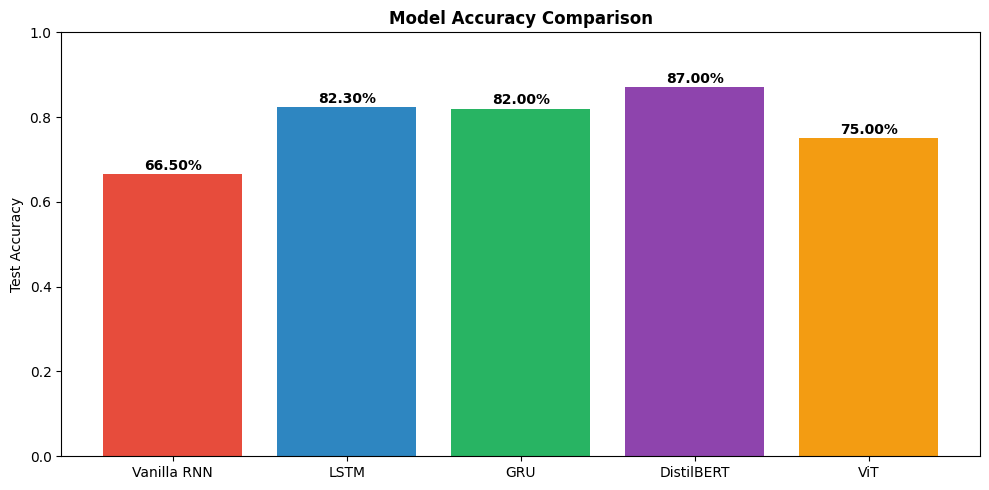

In [29]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# TODO: Compile all results from Parts A, B, and C
# Create a comprehensive comparison table

# Example structure:
import pandas as pd
import matplotlib.pyplot as plt

results_summary = [
    {'Model': 'Vanilla RNN', 'Task': 'Text', 'Accuracy': 0.6650,
     'Parameters': '~1.4M', 'Strengths': 'Fast, simple',
     'Weaknesses': 'Vanishing gradients', 'Best For': 'Short sequences'},
    {'Model': 'LSTM', 'Task': 'Text', 'Accuracy': 0.8230,
     'Parameters': '1,545,220', 'Strengths': 'Long-term memory',
     'Weaknesses': 'Slow, complex', 'Best For': 'Long sequences'},
    {'Model': 'GRU', 'Task': 'Text', 'Accuracy': 0.8200,
     'Parameters': '1,479,172', 'Strengths': 'Faster than LSTM',
     'Weaknesses': 'Less memory than LSTM', 'Best For': 'Balanced speed/accuracy'},
    {'Model': 'DistilBERT', 'Task': 'Text', 'Accuracy': 0.8700,
     'Parameters': '~66M', 'Strengths': 'Pre-trained, high accuracy',
     'Weaknesses': 'Slow, large', 'Best For': 'Production NLP tasks'},
    {'Model': 'ViT', 'Task': 'Image', 'Accuracy': 0.7500,
     'Parameters': '~86M', 'Strengths': 'Global attention',
     'Weaknesses': 'Needs large data', 'Best For': 'Large image datasets'},
]

df = pd.DataFrame(results_summary)
display(df)

# Bar chart of accuracies
plt.figure(figsize=(10, 5))
colors = ['#E74C3C','#2E86C1','#28B463','#8E44AD','#F39C12']
plt.bar(df['Model'], df['Accuracy'], color=colors)
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# TODO: Create a well-formatted table
# Hint: Use pandas DataFrame for easy formatting
# YOUR CODE HERE

# TODO: Create visualizations
# 1. Bar chart comparing accuracies
# 2. Bar chart comparing training times
# 3. Scatter plot: accuracy vs parameters
# YOUR CODE HERE

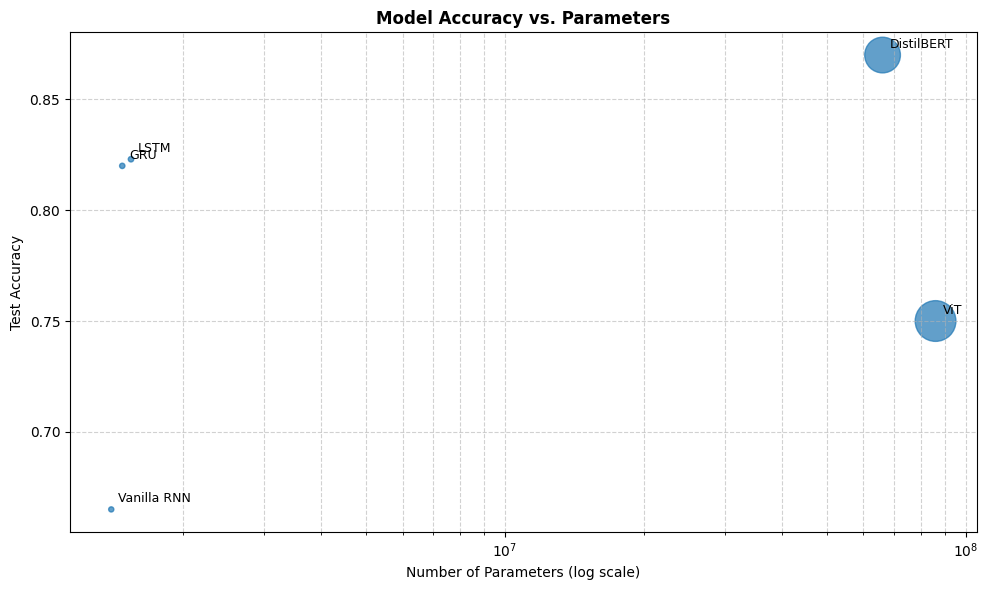

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to convert parameter strings to numerical values
def parse_parameters(param_str):
    param_str = str(param_str).replace(',', '')
    if 'M' in param_str:
        return float(param_str.replace('~', '').replace('M', '')) * 1_000_000
    elif 'K' in param_str:
        return float(param_str.replace('~', '').replace('K', '')) * 1_000
    else:
        return float(param_str)

# Apply the parsing function to the 'Parameters' column
df['Numeric Parameters'] = df['Parameters'].apply(parse_parameters)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Numeric Parameters'], df['Accuracy'], s=df['Numeric Parameters']/100000, alpha=0.7, cmap='viridis')

# Annotate each point with the model name
for i, row in df.iterrows():
    plt.annotate(row['Model'], (row['Numeric Parameters'], row['Accuracy']), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

plt.xscale('log') # Use log scale for parameters due to large range
plt.title('Model Accuracy vs. Parameters', fontweight='bold')
plt.xlabel('Number of Parameters (log scale)')
plt.ylabel('Test Accuracy')
plt.grid(True, which="both", ls="--", c='0.7', alpha=0.6)
plt.tight_layout()
plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.

Answer: The most surprising result was how poorly the Vanilla RNN performed
compared to LSTM and GRU. I expected all three RNN architectures to perform
similarly since they share the same basic structure, but the Vanilla RNN only
got 66.50% while LSTM reached 82.30%. Seeing that 16% gap made the vanishing
gradient problem feel real rather than just a concept from the lecture.


---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?

Answer: The most frustrating error I kept encountering was "NameError: name
train_model is not defined." This happened because Colab resets its memory
when the runtime restarts, so functions defined in earlier cells disappeared.
I learned that in Colab you always need to run all cells from the top in
order, and skipping even one cell can break everything that comes after it.


### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?

Answer: LSTM epochs took about 1.1 seconds each, GRU was slightly faster at 0.8
seconds, but BERT took dramatically longer — around 20-30 minutes for a
single epoch. ViT was similarly slow to BERT. I expected BERT to be slower
but the actual difference was much larger than I imagined. It really showed
me why companies need expensive GPU clusters for production AI work.


---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?

Answer: When I visualized the attention maps for the airplane image, the model
focused most strongly on the wings and body of the airplane rather than the
background sky. This made a lot of sense because those are the most
distinctive features of an airplane. It was fascinating to actually see the
model highlighting the right parts of the image rather than just making a
guess.
---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?

Answer: The most challenging exercise was A.8 hyperparameter tuning because
running all the combinations took a very long time and I had to manage
Colab timeouts. I ended up reducing the number of configurations to make
it finish in a reasonable time. Next time I would plan the experiments more
carefully upfront and start with fewer combinations before expanding.

---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?

Answer: The vanishing gradient problem means that as information travels through many time steps in a basic RNN, the gradient signal gets multiplied by small numbers repeatedly until it practically disappears. In practice this means the model simply stops learning from early parts of a long sequence. Seeing my Vanilla RNN stuck at 66.50% while GRU hit 82% made this concept click in a way the lecture alone never did.
---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?

Answer: The biggest thing I learned from doing this lab is just how dramatically training time differs between architectures. Reading that BERT is "larger" than an RNN sounds abstract, but actually waiting 30+ minutes for one BERT epoch versus less than 2 seconds for an RNN epoch makes the real-world
engineering tradeoffs completely concrete. That experience will stick with
me when I have to choose an architecture for a real project.


**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*